# 📉 Telecom Customer Churn Analysis

**Objective:** Identify which customer segments are most likely to churn, quantify the revenue at risk, and translate findings into retention recommendations for a telecom subscription business.

**Dataset:** IBM Telco Customer Churn (7,043 customers) — includes demographics, account/contract details, service subscriptions, satisfaction/churn scores, and stated churn reasons.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sqlite3

## 1. Data Ingestion
Loading the cleaned Telco churn dataset from SQLite.

In [2]:
df_telco = pd.read_excel("../data/raw/Telco_customer_churn.xlsx", sheet_name="Telco_Churn")

rename_map = {
    "CustomerID": "customerid", "Country": "country", "State": "state", "City": "city",
    "Gender": "gender", "Senior Citizen": "senior_citizen", "Partner": "partner",
    "Dependents": "dependents", "Tenure Months": "tenure_months", "Phone Service": "phone_service",
    "Multiple Lines": "multiple_lines", "Internet Service": "internet_service",
    "Online Security": "online_security", "Online Backup": "online_backup",
    "Device Protection": "device_protection", "Tech Support": "tech_support",
    "Streaming TV": "streaming_tv", "Streaming Movies": "streaming_movies",
    "Contract": "contract_type", "Paperless Billing": "paperless_billing",
    "Payment Method": "payment_method", "Monthly Charges": "monthly_charges",
    "Total Charges": "total_charges", "Churn Label": "churn_label",
    "Churn Value": "churn_flag", "Churn Score": "churn_score", "CLTV": "cltv",
    "Churn Reason": "cancellation_reason",
}

df_telco = df_telco.rename(columns=rename_map)
df_telco = df_telco.drop(columns=["Count", "Zip Code", "Lat Long", "Latitude", "Longitude"])
df_telco.columns.tolist()

['customerid',
 'country',
 'state',
 'city',
 'gender',
 'senior_citizen',
 'partner',
 'dependents',
 'tenure_months',
 'phone_service',
 'multiple_lines',
 'internet_service',
 'online_security',
 'online_backup',
 'device_protection',
 'tech_support',
 'streaming_tv',
 'streaming_movies',
 'contract_type',
 'paperless_billing',
 'payment_method',
 'monthly_charges',
 'total_charges',
 'churn_label',
 'churn_flag',
 'churn_score',
 'cltv',
 'cancellation_reason']

In [3]:
with sqlite3.connect("../data/raw/customer_churn.db") as conn:
    df_telco.to_sql("telco_churn", conn, if_exists="replace", index=False)

print("Saved. Table name: telco_churn")

Saved. Table name: telco_churn


In [4]:
with sqlite3.connect("../data/raw/customer_churn.db") as conn:
    df = pd.read_sql("SELECT * FROM telco_churn", conn)

print(df.shape)
df.head()

(7043, 28)


,customerid,country,state,city,gender,senior_citizen,partner,dependents,tenure_months,phone_service,...,contract_type,paperless_billing,payment_method,monthly_charges,total_charges,churn_label,churn_flag,churn_score,cltv,cancellation_reason
0,3668-QPYBK,United States,California,Los Angeles,Male,No,No,No,2,Yes,...,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1,86,3239,Competitor made better offer
1,9237-HQITU,United States,California,Los Angeles,Female,No,No,Yes,2,Yes,...,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1,67,2701,Moved
2,9305-CDSKC,United States,California,Los Angeles,Female,No,No,Yes,8,Yes,...,Month-to-month,Yes,Electronic check,99.65,820.5,Yes,1,86,5372,Moved
3,7892-POOKP,United States,California,Los Angeles,Female,No,Yes,Yes,28,Yes,...,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes,1,84,5003,Moved
4,0280-XJGEX,United States,California,Los Angeles,Male,No,No,Yes,49,Yes,...,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.3,Yes,1,89,5340,Competitor had better devices


In [5]:
df[df['total_charges'].apply(lambda x: isinstance(x, str) and x.strip() == '')]

,customerid,country,state,city,gender,senior_citizen,partner,dependents,tenure_months,phone_service,...,contract_type,paperless_billing,payment_method,monthly_charges,total_charges,churn_label,churn_flag,churn_score,cltv,cancellation_reason
2234,4472-LVYGI,United States,California,San Bernardino,Female,No,Yes,No,0,No,...,Two year,Yes,Bank transfer (automatic),52.55,,No,0,36,2578,NaN
2438,3115-CZMZD,United States,California,Independence,Male,No,No,No,0,Yes,...,Two year,No,Mailed check,20.25,,No,0,68,5504,NaN
2568,5709-LVOEQ,United States,California,San Mateo,Female,No,Yes,No,0,Yes,...,Two year,No,Mailed check,80.85,,No,0,45,2048,NaN
2667,4367-NUYAO,United States,California,Cupertino,Male,No,Yes,Yes,0,Yes,...,Two year,No,Mailed check,25.75,,No,0,48,4950,NaN
2856,1371-DWPAZ,United States,California,Redcrest,Female,No,Yes,No,0,No,...,Two year,No,Credit card (automatic),56.05,,No,0,30,4740,NaN
4331,7644-OMVMY,United States,California,Los Angeles,Male,No,Yes,Yes,0,Yes,...,Two year,No,Mailed check,19.85,,No,0,53,2019,NaN
4687,3213-VVOLG,United States,California,Sun City,Male,No,Yes,Yes,0,Yes,...,Two year,No,Mailed check,25.35,,No,0,49,2299,NaN
5104,2520-SGTTA,United States,California,Ben Lomond,Female,No,Yes,Yes,0,Yes,...,Two year,No,Mailed check,20.00,,No,0,27,3763,NaN
5719,2923-ARZLG,United States,California,La Verne,Male,No,Yes,Yes,0,Yes,...,One year,Yes,Mailed check,19.70,,No,0,69,4890,NaN
6772,4075-WKNIU,United States,California,Bell,Female,No,Yes,Yes,0,Yes,...,Two year,No,Mailed check,73.35,,No,0,44,2342,NaN


In [6]:
df['tenure_months'].describe()

count    7043.000000
mean       32.371149
std        24.559481
min         0.000000
25%         9.000000
50%        29.000000
75%        55.000000
max        72.000000
Name: tenure_months, dtype: float64

## 2. Data Cleaning
total_charges problem
total_charges has some blank spaces in it. checked those rows and tenure_months is 0 for all of them, so basically new customers who havent gotten a bill yet. makes sense why its blank then. gonna fill it with 0 instead of dropping anything since we actually know the reason behind it.

In [7]:
df['total_charges'] = df['total_charges'].replace(' ', '0')
df['total_charges'] = pd.to_numeric(df['total_charges'])
df['total_charges'].dtype

dtype('float64')

In [8]:
for col in ['senior_citizen', 'partner', 'dependents', 'phone_service', 'paperless_billing']:
    print(col, ":", df[col].unique())

senior_citizen : <StringArray>
['No', 'Yes']
Length: 2, dtype: str
partner : <StringArray>
['No', 'Yes']
Length: 2, dtype: str
dependents : <StringArray>
['No', 'Yes']
Length: 2, dtype: str
phone_service : <StringArray>
['Yes', 'No']
Length: 2, dtype: str
paperless_billing : <StringArray>
['Yes', 'No']
Length: 2, dtype: str


In [9]:
# converting the yes/no columns into 0/1 flags, same pattern as the service columns below
# keeping the original text columns too, just adding new _flag versions
yes_no_cols = ['senior_citizen', 'partner', 'dependents', 'phone_service', 'paperless_billing']

for col in yes_no_cols:
    df[col + '_flag'] = (df[col] == 'Yes').astype(int)

df[[c + '_flag' for c in yes_no_cols]].head()

,senior_citizen_flag,partner_flag,dependents_flag,phone_service_flag,paperless_billing_flag
0,0,0,0,1,1
1,0,0,1,1,1
2,0,0,1,1,1
3,0,1,1,1,1
4,0,0,1,1,1


In [10]:
three_value_cols = ['online_security', 'online_backup', 'device_protection',
                     'tech_support', 'streaming_tv', 'streaming_movies']

for col in three_value_cols:
    df[col + '_flag'] = (df[col] == 'Yes').astype(int)

df['multiple_lines_flag'] = (df['multiple_lines'] == 'Yes').astype(int)

df[[c + '_flag' for c in three_value_cols] + ['multiple_lines_flag']].head()

,online_security_flag,online_backup_flag,device_protection_flag,tech_support_flag,streaming_tv_flag,streaming_movies_flag,multiple_lines_flag
0,1,1,0,0,0,0,0
1,0,0,0,0,0,0,0
2,0,0,1,0,1,1,1
3,0,0,1,1,1,1,1
4,0,1,1,0,1,1,1


In [11]:
service_cols = ['online_security', 'online_backup', 'device_protection', 'tech_support',
                'streaming_tv', 'streaming_movies', 'multiple_lines']

for col in service_cols:
    print(col, ":", df[col].unique())

online_security : <StringArray>
['Yes', 'No', 'No internet service']
Length: 3, dtype: str
online_backup : <StringArray>
['Yes', 'No', 'No internet service']
Length: 3, dtype: str
device_protection : <StringArray>
['No', 'Yes', 'No internet service']
Length: 3, dtype: str
tech_support : <StringArray>
['No', 'Yes', 'No internet service']
Length: 3, dtype: str
streaming_tv : <StringArray>
['No', 'Yes', 'No internet service']
Length: 3, dtype: str
streaming_movies : <StringArray>
['No', 'Yes', 'No internet service']
Length: 3, dtype: str
multiple_lines : <StringArray>
['No', 'Yes', 'No phone service']
Length: 3, dtype: str


In [12]:
df['churn_flag'].value_counts()


churn_flag
0    5174
1    1869
Name: count, dtype: int64

In [13]:

df['churn_flag'].isna().sum()

np.int64(0)

In [14]:
df = df.drop(columns=['churn_label'])

In [15]:
'churn_label' in df.columns

False

### Categorical Cleanup Summary 
in these previous steps i converted yes/no columns into 0/1 flags, keeping the original text columns too so its still readable. for online_security, tech_support, streaming_tv etc, some rows said "no internet service" instead of just "no" - treated those as 0 as well since it means the same thing practically, they just dont have the service. same thing for multiple_lines and "no phone service". also dropped churn_label since it duplicated churn_flag (same info, just yes/no vs 1/0).

In [16]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 39 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   customerid              7043 non-null   str    
 1   country                 7043 non-null   str    
 2   state                   7043 non-null   str    
 3   city                    7043 non-null   str    
 4   gender                  7043 non-null   str    
 5   senior_citizen          7043 non-null   str    
 6   partner                 7043 non-null   str    
 7   dependents              7043 non-null   str    
 8   tenure_months           7043 non-null   int64  
 9   phone_service           7043 non-null   str    
 10  multiple_lines          7043 non-null   str    
 11  internet_service        7043 non-null   str    
 12  online_security         7043 non-null   str    
 13  online_backup           7043 non-null   str    
 14  device_protection       7043 non-null   str    
 15

In [17]:
df.describe()

,tenure_months,monthly_charges,total_charges,churn_flag,churn_score,cltv,senior_citizen_flag,partner_flag,dependents_flag,phone_service_flag,paperless_billing_flag,online_security_flag,online_backup_flag,device_protection_flag,tech_support_flag,streaming_tv_flag,streaming_movies_flag,multiple_lines_flag
count,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000
mean,32.371149,64.761692,2279.734304,0.265370,58.699418,4400.295755,0.162147,0.483033,0.231010,0.903166,0.592219,0.286668,0.344881,0.343888,0.290217,0.384353,0.387903,0.421837
std,24.559481,30.090047,2266.794470,0.441561,21.525131,1183.057152,0.368612,0.499748,0.421508,0.295752,0.491457,0.452237,0.475363,0.475038,0.453895,0.486477,0.487307,0.493888
min,0.000000,18.250000,0.000000,0.000000,5.000000,2003.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,9.000000,35.500000,398.550000,0.000000,40.000000,3469.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,29.000000,70.350000,1394.550000,0.000000,61.000000,4527.000000,0.000000,0.000000,0.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,55.000000,89.850000,3786.600000,1.000000,75.000000,5380.500000,0.000000,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
max,72.000000,118.750000,8684.800000,1.000000,100.000000,6500.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


## 3. KPI & Business Metrics
## What will happen next
Now that the data is cleaned, we will calculate the core business KPIs — the numbers a stakeholder would actually want to see first to understand how the business is doing.

1. **Churn Rate** – First, I will calculate the churn rate using the churn_flag column. Since this column contains 1 for churned customers and 0 for active customers, it can be used to determine the percentage of customers who have left the service.
2. **Retention Rate** – Next, I will calculate the retention rate, which is simply the opposite of the churn rate. It shows the percentage of customers who have stayed with the company.
3. **ARPU (Average Revenue Per User)** – This metric will be calculated by taking the average of all values in the monthly_charges column. It helps estimate how much revenue an average customer generates each month.
4. **Revenue at Risk** – For this KPI, I will focus only on customers whose churn_flag is equal to 1. By summing their monthly charges, I can estimate the amount of revenue that is being lost due to customer churn.

In [18]:
# churn rate - basically the average of churn_flag since its 0/1
# whatever % is 1, thats our churn rate
churn_rate = round(df['churn_flag'].mean() * 100, 2)
print("Churn Rate (%):", churn_rate)

Churn Rate (%): 26.54


In [19]:
# retention is just the opposite of churn, 100 minus churn rate
retention_rate = round((1 - df['churn_flag'].mean()) * 100, 2)
print("Retention Rate (%):", retention_rate)

Retention Rate (%): 73.46


In [20]:
# arpu = avg revenue per user, just taking mean of monthly_charges across everyone
# roughly tells us what one customer is worth per month
arpu = round(df['monthly_charges'].mean(), 2)
print("ARPU ($):", arpu)

ARPU ($): 64.76


In [21]:
# how many months ppl stick around on avg
avg_tenure = round(df['tenure_months'].mean(), 1)
print("Average Tenure (months):", avg_tenure)

Average Tenure (months): 32.4


In [22]:
# revenue at risk - only looking at customers who actually churned (churn_flag == 1)
# summing up their monthly_charges to see how much revenue we lost per month
revenue_at_risk_monthly = round(df.loc[df['churn_flag'] == 1, 'monthly_charges'].sum(), 2)
print("Monthly Revenue at Risk ($):", revenue_at_risk_monthly)

Monthly Revenue at Risk ($): 139130.85


In [23]:
# same number just x12, easier for a business person to think in yearly $ instead of monthly
revenue_at_risk_annual = round(revenue_at_risk_monthly * 12, 2)
print("Annualized Revenue at Risk ($):", revenue_at_risk_annual)

Annualized Revenue at Risk ($): 1669570.2


In [24]:
# putting everything together into one table so its easy to just glance at all the kpis at once
kpis = {
    "Total Customers": len(df),
    "Churn Rate (%)": churn_rate,
    "Retention Rate (%)": retention_rate,
    "ARPU ($)": arpu,
    "Average Tenure (months)": avg_tenure,
    "Monthly Revenue at Risk ($)": revenue_at_risk_monthly,
    "Annualized Revenue at Risk ($)": revenue_at_risk_annual,
}

kpi_df = pd.DataFrame(kpis.items(), columns=["Metric", "Value"])
kpi_df

,Metric,Value
0,Total Customers,7043.00
1,Churn Rate (%),26.54
2,Retention Rate (%),73.46
3,ARPU ($),64.76
4,Average Tenure (months),32.40
5,Monthly Revenue at Risk ($),139130.85
6,Annualized Revenue at Risk ($),1669570.20


In [25]:
# groupby('churn_flag') splits the whole dataframe into two groups: 
# one group where churn_flag == 0 (retained customers), one where churn_flag == 1 (churned)
# then ['cltv'].mean() calculates the average CLTV separately for each of those two groups
# so we end up with 2 numbers: avg CLTV for people who stayed, avg CLTV for people who left
cltv_by_churn = df.groupby('churn_flag')['cltv'].mean().round(2)

In [26]:
# this one doesn't group anything - it filters the dataframe down to ONLY 
# the rows where churn_flag == 1 (only churned customers), 
# grabs their 'cltv' column, and adds it all up with .sum()
# so this is: total lifetime value that walked out the door across every churned customer
total_cltv_at_risk = df.loc[df['churn_flag'] == 1, 'cltv'].sum()

In [27]:
print(cltv_by_churn)
print("Total CLTV at risk ($):", round(total_cltv_at_risk, 2))

churn_flag
0    4490.92
1    4149.41
Name: cltv, dtype: float64
Total CLTV at risk ($): 7755256


 churned customers have slightly lower average CLTV than retained ones ($4,149 vs $4,491) — not a huge gap, so it's not like we're only losing low-value customers. But in total, $7.75M in CLTV walked out the door with churned customers.

In [28]:
num_churned = df['churn_flag'].sum()
check = 4149.41 * num_churned
print(num_churned, check)

1869 7755247.29


In [29]:
# grouping by contract_type, then looking at avg churn_flag within each group
# same idea as the cltv groupby from before - split into groups first, then average within each
churn_by_contract = df.groupby('contract_type')['churn_flag'].mean().round(4) * 100
churn_by_contract = churn_by_contract.round(2)


In [30]:
# also want to know HOW MANY customers are in each group, not just the rate
# a 50% churn rate means something very different if its 4 customers vs 4000
contract_counts = df['contract_type'].value_counts()

print(churn_by_contract)
print()
print(contract_counts)

contract_type
Month-to-month    42.71
One year          11.27
Two year           2.83
Name: churn_flag, dtype: float64

contract_type
Month-to-month    3875
Two year          1695
One year          1473
Name: count, dtype: int64


## 4. Segment-Level Churn Analysis
## Churn by Contract-Type
to understand which contract has most impact on churn_flag i have analysed the churn rate of various contracts 
the result shown by analysing shows a very clear pattern in which customers with contract type of month-to-month has highest churn rate of 42.71%

followed by one- year of 11.27%

followed by 2 year of 2.83%

Looking at the data i can say that  :-
Customers on month-to-month plans can leave at any time without a long-term commitment, making it much easier for them to switch to competitors or cancel the service if they are dissatisfied. On the other hand, customers with one-year or two-year contracts have already committed to the service for a longer period, making them less likely to churn.
From this data i can say that company should focus on encouraging the month-to-month customers to move to longer term contract period
this could be done through various opportunities given to customers like discount,loyalty and many more.


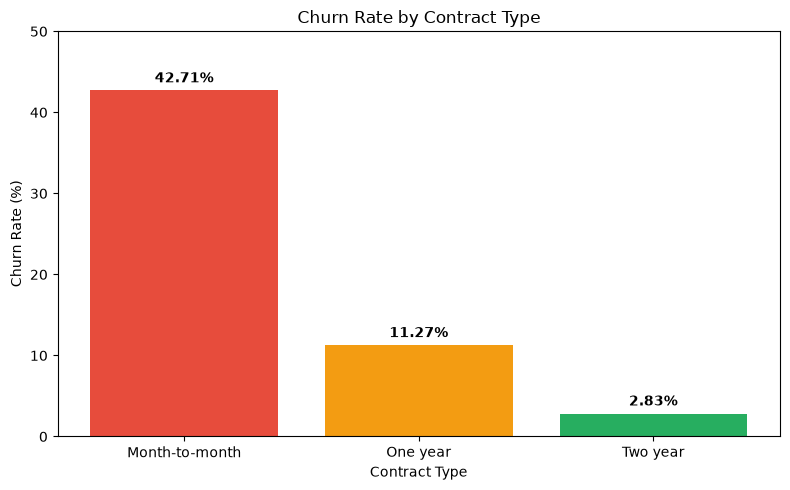

In [31]:
plt.figure(figsize=(8, 5))

# order matters here - want month-to-month, one year, two year in that logical order
# not alphabetical, which is what pandas would default to
order = ['Month-to-month', 'One year', 'Two year']
churn_by_contract_ordered = churn_by_contract.reindex(order)

plt.bar(churn_by_contract_ordered.index, churn_by_contract_ordered.values, color=['#e74c3c', '#f39c12', '#27ae60'])

plt.title('Churn Rate by Contract Type')
plt.xlabel('Contract Type')
plt.ylabel('Churn Rate (%)')

# rotation=0 keeps the contract-type names horizontal instead of angled
# (they're short enough here that angling isn't needed, unlike the state names in your old notebook)
plt.xticks(rotation=0)
plt.ylim(0, 50)


# adding the actual % on top of each bar so its readable at a glance, not just guessing from the bar height
for i, val in enumerate(churn_by_contract_ordered.values):
    plt.text(i, val + 1, f'{val}%', ha='center', fontweight='bold')


plt.tight_layout()
import os
os.makedirs('../images', exist_ok=True)    
# dpi=150 = higher resolution, looks sharp instead of blurry when you embed it in your README later
plt.savefig('../images/churn_by_contract.png', dpi=150)    

plt.show()

In [32]:
# services_count - adding up how many of the add-on services each customer has
# reusing the _flag columns we already made in phase 2, no need to touch raw text columns again
service_flag_cols = ['online_security_flag', 'online_backup_flag', 'device_protection_flag',
                      'tech_support_flag', 'streaming_tv_flag', 'streaming_movies_flag']

df['services_count'] = df[service_flag_cols].sum(axis=1)

df['services_count'].value_counts().sort_index()

services_count
0    2219
1     966
2    1033
3    1118
4     852
5     571
6     284
Name: count, dtype: int64

In [33]:
# tenure_cohort - bucketing tenure_months into lifecycle stages instead of one raw number
# pd.cut splits a numeric column into ranges (bins) and labels them
bins = [-1, 12, 24, 48, 72]
labels = ['New (0-12mo)', 'Growing (13-24mo)', 'Established (25-48mo)', 'Loyal (49-72mo)']

df['tenure_cohort'] = pd.cut(df['tenure_months'], bins=bins, labels=labels)

df['tenure_cohort'].value_counts()

tenure_cohort
Loyal (49-72mo)          2239
New (0-12mo)             2186
Established (25-48mo)    1594
Growing (13-24mo)        1024
Name: count, dtype: int64

In [34]:
# same groupby pattern as contract_type - split by internet_service, average churn_flag within each group
churn_by_internet = df.groupby('internet_service')['churn_flag'].mean().round(4) * 100
churn_by_internet = churn_by_internet.round(2)

# counts too, same reason as before - a % means nothing without knowing the group size
internet_counts = df['internet_service'].value_counts()

print(churn_by_internet)
print()
print(internet_counts)

internet_service
DSL            18.96
Fiber optic    41.89
No              7.40
Name: churn_flag, dtype: float64

internet_service
Fiber optic    3096
DSL            2421
No             1526
Name: count, dtype: int64


In [35]:
# checking if fiber customers are paying noticeably more - price could explain the higher churn
avg_charges_by_internet = df.groupby('internet_service')['monthly_charges'].mean().round(2)
print(avg_charges_by_internet)

internet_service
DSL            58.10
Fiber optic    91.50
No             21.08
Name: monthly_charges, dtype: float64


## Churn Analysis by Internet Service Type
I wanted to see whether the type of internet service affects customer churn. I found that Fiber Optic customers have the highest churn rate at 41.89%, followed by DSL customers at 18.96%, and lastly customers without internet service at 7.40%.

I was surprised by this result, as fiber optic internet is usually considered the best service available — but the churn data says otherwise.

To understand why this might be happening, I looked into the average monthly charges for each service type and found that Fiber Optic customers pay USD 91.50/month on average, while DSL customers pay USD 58.10/month. From this, I can conclude that higher prices are likely one of the reasons behind the increased churn for fiber customers.

Instead of focusing only on acquiring new customers, the company should also investigate why fiber optic customers are leaving — looking into customer feedback, complaints, and the specific issues they're facing. The company should prioritize building loyalty among existing customers rather than just acquiring new ones. Retention tools like discounts and loyalty rewards could help specifically for this segment.

In [36]:
churn_by_payment = df.groupby('payment_method')['churn_flag'].mean().round(4) * 100
churn_by_payment = churn_by_payment.round(2)

payment_counts = df['payment_method'].value_counts()

print(churn_by_payment)
print()
print(payment_counts)

payment_method
Bank transfer (automatic)    16.71
Credit card (automatic)      15.24
Electronic check             45.29
Mailed check                 19.11
Name: churn_flag, dtype: float64

payment_method
Electronic check             2365
Mailed check                 1612
Bank transfer (automatic)    1544
Credit card (automatic)      1522
Name: count, dtype: int64


## Churn Analysis by Payment Method
wanted to check if payment method has any effect on churn. turns out electronic check customers have by far the highest churn rate at 45.29%, then mailed check at 19.11%, bank transfer (automatic) at 16.71%, and credit card (automatic) at 15.24%.

honestly kind of surprised how big the gap is - almost half of electronic check customers have churned, while the automatic payment methods are sitting way lower.

my guess for why - automatic payments (credit card, bank transfer) just deduct the bill every month without the customer having to do anything. electronic check on the other hand needs the customer to actually log in and pay manually each time, which means more friction and more chances for them to just stop paying or reconsider staying.

electronic check is also the most used payment method (2,365 customers), so its not just a high churn rate on a small group - this is a big chunk of the customer base actively causing a lot of the churn.

company should probably focus on moving people off electronic check and onto autopay - could offer small discounts, cashback, or some kind of loyalty perk for enrolling in automatic payments. less friction generally = customers stick around longer, based on the pattern here.

In [37]:
churn_by_services = df.groupby('services_count')['churn_flag'].mean().round(4) * 100
churn_by_services = churn_by_services.round(2)

services_counts = df['services_count'].value_counts().sort_index()

print(churn_by_services)
print()
print(services_counts)

services_count
0    21.41
1    45.76
2    35.82
3    27.37
4    22.30
5    12.43
6     5.28
Name: churn_flag, dtype: float64

services_count
0    2219
1     966
2    1033
3    1118
4     852
5     571
6     284
Name: count, dtype: int64


In [38]:
# cross-tab: for each internet_service type, whats the average services_count
# if "No" internet customers are dragging down the 0-services churn number, this will show it clearly
df.groupby('internet_service')['services_count'].mean().round(2)

internet_service
DSL            2.66
Fiber optic    2.55
No             0.00
Name: services_count, dtype: float64

In [39]:
# more direct check - only look at customers who HAVE internet, then redo the services_count churn breakdown
# this removes the "No internet" customers from the mix entirely
df_has_internet = df[df['internet_service'] != 'No']
churn_by_services_internet_only = df_has_internet.groupby('services_count')['churn_flag'].mean().round(4) * 100
print(churn_by_services_internet_only.round(2))


services_count
0    52.24
1    45.76
2    35.82
3    27.37
4    22.30
5    12.43
6     5.28
Name: churn_flag, dtype: float64


## Churn by Number of Add-on Services
wanted to check if having more add-on services (security, backup, tech support, streaming etc) makes customers stick around longer. first pass looked weird though - 0 services showed 21.41% churn, then jumped UP to 45.76% at 1 service, then started dropping steadily after that. didn't make sense for the theory that more services = more sticky.

turned out to be a mixing problem - customers with "No" internet service automatically have services_count = 0 too, since none of these services work without internet. and no-internet customers already had really low churn (7.40%) for a totally different reason. so the 0-services group was actually a blend of two different types of customers, which threw off the pattern.

reran it after filtering out customers with no internet entirely, and the real pattern showed up clean: churn drops steadily from 52.24% at 0 services all the way down to 5.28% at 6 services. so the original theory was right - it was just getting hidden by a confound.

worth remembering this - always check if a weird number might be two different groups accidentally mixed together before assuming the pattern is actually broken.

In [40]:
churn_by_tenure_cohort = df.groupby('tenure_cohort', observed=True)['churn_flag'].mean().round(4) * 100
print(churn_by_tenure_cohort.round(2))

tenure_cohort
New (0-12mo)             47.44
Growing (13-24mo)        28.71
Established (25-48mo)    20.39
Loyal (49-72mo)           9.51
Name: churn_flag, dtype: float64


## Churn by Cancellation Reason (Categorized)
the raw cancellation_reason column had 20 different specific reasons, way too many to chart or draw conclusions from directly. grouped them into 5 broader categories instead - Competitor, Service/Support, Product/Network, Price, and Other/Non-actionable - based on what each reason was actually pointing at.

biggest one by far is Competitor at 33.23% (621 customers) - more than Price and Product/Network combined. so the main reason people are leaving isnt that the service is bad or too expensive, its that competitors are actively pulling customers away with better offers, speeds, data, or devices.

Service/Support (24.29%) and Product/Network (20.44%) come next, together almost 45% of churn - and these are both things the company can directly fix, unlike competitor pressure which is more external.

kind of surprising - Price is actually the SMALLEST actionable category at 10.65%. would've assumed price was a bigger factor going in, but the data says otherwise.

so the obvious "just lower prices" reaction probably isnt the right move here. bigger opportunity seems to be in two places: (1) competing more aggressively on offers/speed/data before customers even start shopping around, and (2) fixing internal service and product issues, since those are fully within the company's control and make up almost half of all churn combined.

In [41]:
# only looking at customers who actually churned, since only they have a reason filled in
cancellation_counts = df.loc[df['churn_flag'] == 1, 'cancellation_reason'].value_counts()
print(cancellation_counts)

cancellation_reason
Attitude of support person                   192
Competitor offered higher download speeds    189
Competitor offered more data                 162
Don't know                                   154
Competitor made better offer                 140
Attitude of service provider                 135
Competitor had better devices                130
Network reliability                          103
Product dissatisfaction                      102
Price too high                                98
Service dissatisfaction                       89
Lack of self-service on Website               88
Extra data charges                            57
Moved                                         53
Limited range of services                     44
Lack of affordable download/upload speed      44
Long distance charges                         44
Poor expertise of phone support               20
Poor expertise of online support              19
Deceased                                       6


In [42]:
# grouping raw reasons into broader categories - makes this actually chartable
# and each category points to a different team/fix (competitor, service, product, price, other)
reason_categories = {
    'Competitor offered higher download speeds': 'Competitor',
    'Competitor offered more data': 'Competitor',
    'Competitor made better offer': 'Competitor',
    'Competitor had better devices': 'Competitor',
    'Attitude of support person': 'Service/Support',
    'Attitude of service provider': 'Service/Support',
    'Poor expertise of phone support': 'Service/Support',
    'Poor expertise of online support': 'Service/Support',
    'Lack of self-service on Website': 'Service/Support',
    'Network reliability': 'Product/Network',
    'Product dissatisfaction': 'Product/Network',
    'Service dissatisfaction': 'Product/Network',
    'Limited range of services': 'Product/Network',
    'Lack of affordable download/upload speed': 'Product/Network',
    'Price too high': 'Price',
    'Extra data charges': 'Price',
    'Long distance charges': 'Price',
    "Don't know": 'Other/Non-actionable',
    'Moved': 'Other/Non-actionable',
    'Deceased': 'Other/Non-actionable',
}

df['cancellation_category'] = df['cancellation_reason'].map(reason_categories)


In [43]:
category_counts = df.loc[df['churn_flag'] == 1, 'cancellation_category'].value_counts()
category_pct = (category_counts / category_counts.sum() * 100).round(2)

print(category_counts)
print()
print(category_pct)

cancellation_category
Competitor              621
Service/Support         454
Product/Network         382
Other/Non-actionable    213
Price                   199
Name: count, dtype: int64

cancellation_category
Competitor              33.23
Service/Support         24.29
Product/Network         20.44
Other/Non-actionable    11.40
Price                   10.65
Name: count, dtype: float64


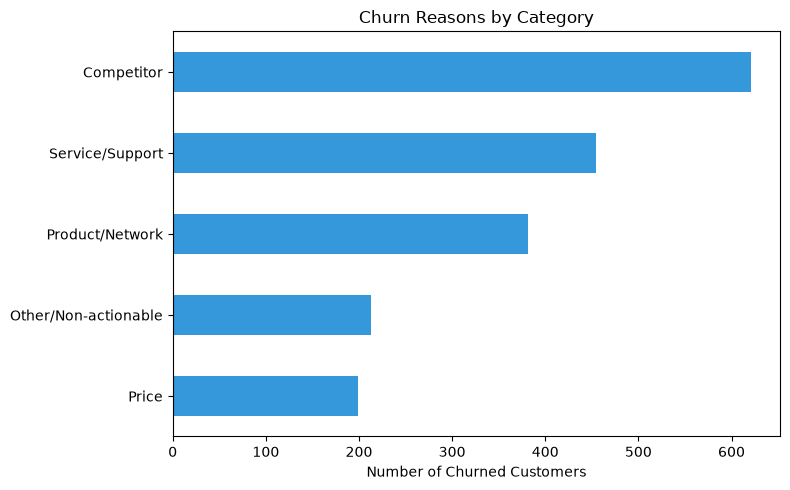

In [44]:
plt.figure(figsize=(8, 5))
category_counts.sort_values().plot(kind='barh', color='#3498db')

plt.title('Churn Reasons by Category')
plt.xlabel('Number of Churned Customers')
plt.ylabel('')
plt.tight_layout()
import os
os.makedirs('../images', exist_ok=True)
plt.savefig('../images/churn_reasons_category.png', dpi=150)
plt.show()

In [45]:
df.head()

,customerid,country,state,city,gender,senior_citizen,partner,dependents,tenure_months,phone_service,...,online_security_flag,online_backup_flag,device_protection_flag,tech_support_flag,streaming_tv_flag,streaming_movies_flag,multiple_lines_flag,services_count,tenure_cohort,cancellation_category
0,3668-QPYBK,United States,California,Los Angeles,Male,No,No,No,2,Yes,...,1,1,0,0,0,0,0,2,New (0-12mo),Competitor
1,9237-HQITU,United States,California,Los Angeles,Female,No,No,Yes,2,Yes,...,0,0,0,0,0,0,0,0,New (0-12mo),Other/Non-actionable
2,9305-CDSKC,United States,California,Los Angeles,Female,No,No,Yes,8,Yes,...,0,0,1,0,1,1,1,3,New (0-12mo),Other/Non-actionable
3,7892-POOKP,United States,California,Los Angeles,Female,No,Yes,Yes,28,Yes,...,0,0,1,1,1,1,1,4,Established (25-48mo),Other/Non-actionable
4,0280-XJGEX,United States,California,Los Angeles,Male,No,No,Yes,49,Yes,...,0,1,1,0,1,1,1,4,Loyal (49-72mo),Competitor


In [46]:
df.tail()

,customerid,country,state,city,gender,senior_citizen,partner,dependents,tenure_months,phone_service,...,online_security_flag,online_backup_flag,device_protection_flag,tech_support_flag,streaming_tv_flag,streaming_movies_flag,multiple_lines_flag,services_count,tenure_cohort,cancellation_category
7038,2569-WGERO,United States,California,Landers,Female,No,No,No,72,Yes,...,0,0,0,0,0,0,0,0,Loyal (49-72mo),NaN
7039,6840-RESVB,United States,California,Adelanto,Male,No,Yes,Yes,24,Yes,...,1,0,1,1,1,1,1,5,Growing (13-24mo),NaN
7040,2234-XADUH,United States,California,Amboy,Female,No,Yes,Yes,72,Yes,...,0,1,1,0,1,1,1,4,Loyal (49-72mo),NaN
7041,4801-JZAZL,United States,California,Angelus Oaks,Female,No,Yes,Yes,11,No,...,1,0,0,0,0,0,0,1,New (0-12mo),NaN
7042,3186-AJIEK,United States,California,Apple Valley,Male,No,No,No,66,Yes,...,1,0,1,1,1,1,0,5,Loyal (49-72mo),NaN


In [47]:
df.describe()

,tenure_months,monthly_charges,total_charges,churn_flag,churn_score,cltv,senior_citizen_flag,partner_flag,dependents_flag,phone_service_flag,paperless_billing_flag,online_security_flag,online_backup_flag,device_protection_flag,tech_support_flag,streaming_tv_flag,streaming_movies_flag,multiple_lines_flag,services_count
count,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000
mean,32.371149,64.761692,2279.734304,0.265370,58.699418,4400.295755,0.162147,0.483033,0.231010,0.903166,0.592219,0.286668,0.344881,0.343888,0.290217,0.384353,0.387903,0.421837,2.037910
std,24.559481,30.090047,2266.794470,0.441561,21.525131,1183.057152,0.368612,0.499748,0.421508,0.295752,0.491457,0.452237,0.475363,0.475038,0.453895,0.486477,0.487307,0.493888,1.847682
min,0.000000,18.250000,0.000000,0.000000,5.000000,2003.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,9.000000,35.500000,398.550000,0.000000,40.000000,3469.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,29.000000,70.350000,1394.550000,0.000000,61.000000,4527.000000,0.000000,0.000000,0.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.000000
75%,55.000000,89.850000,3786.600000,1.000000,75.000000,5380.500000,0.000000,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,3.000000
max,72.000000,118.750000,8684.800000,1.000000,100.000000,6500.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,6.000000


In [48]:
df.columns

Index(['customerid', 'country', 'state', 'city', 'gender', 'senior_citizen',
       'partner', 'dependents', 'tenure_months', 'phone_service',
       'multiple_lines', 'internet_service', 'online_security',
       'online_backup', 'device_protection', 'tech_support', 'streaming_tv',
       'streaming_movies', 'contract_type', 'paperless_billing',
       'payment_method', 'monthly_charges', 'total_charges', 'churn_flag',
       'churn_score', 'cltv', 'cancellation_reason', 'senior_citizen_flag',
       'partner_flag', 'dependents_flag', 'phone_service_flag',
       'paperless_billing_flag', 'online_security_flag', 'online_backup_flag',
       'device_protection_flag', 'tech_support_flag', 'streaming_tv_flag',
       'streaming_movies_flag', 'multiple_lines_flag', 'services_count',
       'tenure_cohort', 'cancellation_category'],
      dtype='str')

In [49]:
# picking out the numeric/flag columns worth checking against each other and against churn
corr_cols = [
    'churn_flag', 'churn_score', 'cltv', 'tenure_months', 'monthly_charges', 'total_charges',
    'services_count', 'senior_citizen_flag', 'partner_flag', 'dependents_flag',
    'phone_service_flag', 'paperless_billing_flag', 'multiple_lines_flag',
    'online_security_flag', 'online_backup_flag', 'device_protection_flag',
    'tech_support_flag', 'streaming_tv_flag', 'streaming_movies_flag'
]

df_corr = df[corr_cols]
df_corr.head()

,churn_flag,churn_score,cltv,tenure_months,monthly_charges,total_charges,services_count,senior_citizen_flag,partner_flag,dependents_flag,phone_service_flag,paperless_billing_flag,multiple_lines_flag,online_security_flag,online_backup_flag,device_protection_flag,tech_support_flag,streaming_tv_flag,streaming_movies_flag
0,1,86,3239,2,53.85,108.15,2,0,0,0,1,1,0,1,1,0,0,0,0
1,1,67,2701,2,70.70,151.65,0,0,0,1,1,1,0,0,0,0,0,0,0
2,1,86,5372,8,99.65,820.50,3,0,0,1,1,1,1,0,0,1,0,1,1
3,1,84,5003,28,104.80,3046.05,4,0,1,1,1,1,1,0,0,1,1,1,1
4,1,89,5340,49,103.70,5036.30,4,0,0,1,1,1,1,0,1,1,0,1,1


In [50]:
# values range from -1 (strong negative relationship) to +1 (strong positive relationship), 0 = no relationship
corr_matrix = df_corr.corr().round(2)
corr_matrix

,churn_flag,churn_score,cltv,tenure_months,monthly_charges,total_charges,services_count,senior_citizen_flag,partner_flag,dependents_flag,phone_service_flag,paperless_billing_flag,multiple_lines_flag,online_security_flag,online_backup_flag,device_protection_flag,tech_support_flag,streaming_tv_flag,streaming_movies_flag
churn_flag,1.00,0.66,-0.13,-0.35,0.19,-0.20,-0.09,0.15,-0.15,-0.25,0.01,0.19,0.04,-0.17,-0.08,-0.07,-0.16,0.06,0.06
churn_score,0.66,1.00,-0.08,-0.22,0.13,-0.12,-0.06,0.10,-0.11,-0.17,0.02,0.13,0.04,-0.12,-0.05,-0.05,-0.11,0.04,0.05
cltv,-0.13,-0.08,1.00,0.40,0.10,0.34,0.19,-0.00,0.14,0.06,0.02,0.01,0.13,0.14,0.14,0.12,0.12,0.10,0.11
tenure_months,-0.35,-0.22,0.40,1.00,0.25,0.83,0.49,0.02,0.38,0.13,0.01,0.01,0.33,0.33,0.36,0.36,0.32,0.28,0.29
monthly_charges,0.19,0.13,0.10,0.25,1.00,0.65,0.72,0.22,0.10,-0.14,0.25,0.35,0.49,0.30,0.44,0.48,0.34,0.63,0.63
total_charges,-0.20,-0.12,0.34,0.83,0.65,1.00,0.74,0.10,0.32,0.03,0.11,0.16,0.47,0.41,0.51,0.52,0.43,0.51,0.52
services_count,-0.09,-0.06,0.19,0.49,0.72,0.74,1.00,0.07,0.20,-0.02,-0.09,0.18,0.29,0.57,0.62,0.69,0.64,0.69,0.69
senior_citizen_flag,0.15,0.10,-0.00,0.02,0.22,0.10,0.07,1.00,0.02,-0.17,0.01,0.16,0.14,-0.04,0.07,0.06,-0.06,0.11,0.12
partner_flag,-0.15,-0.11,0.14,0.38,0.10,0.32,0.20,0.02,1.00,0.36,0.02,-0.01,0.14,0.14,0.14,0.15,0.12,0.12,0.12
dependents_flag,-0.25,-0.17,0.06,0.13,-0.14,0.03,-0.02,-0.17,0.36,1.00,0.00,-0.12,-0.03,0.05,0.00,-0.02,0.03,-0.06,-0.07


In [51]:
# .drop('churn_flag') removes the row comparing churn to itself (always 1.00, not useful)
churn_correlations = corr_matrix['churn_flag'].drop('churn_flag').sort_values(ascending=False)
churn_correlations

churn_score               0.66
monthly_charges           0.19
paperless_billing_flag    0.19
senior_citizen_flag       0.15
streaming_tv_flag         0.06
streaming_movies_flag     0.06
multiple_lines_flag       0.04
phone_service_flag        0.01
device_protection_flag   -0.07
online_backup_flag       -0.08
services_count           -0.09
cltv                     -0.13
partner_flag             -0.15
tech_support_flag        -0.16
online_security_flag     -0.17
total_charges            -0.20
dependents_flag          -0.25
tenure_months            -0.35
Name: churn_flag, dtype: float64

## 5. Correlation Analysis

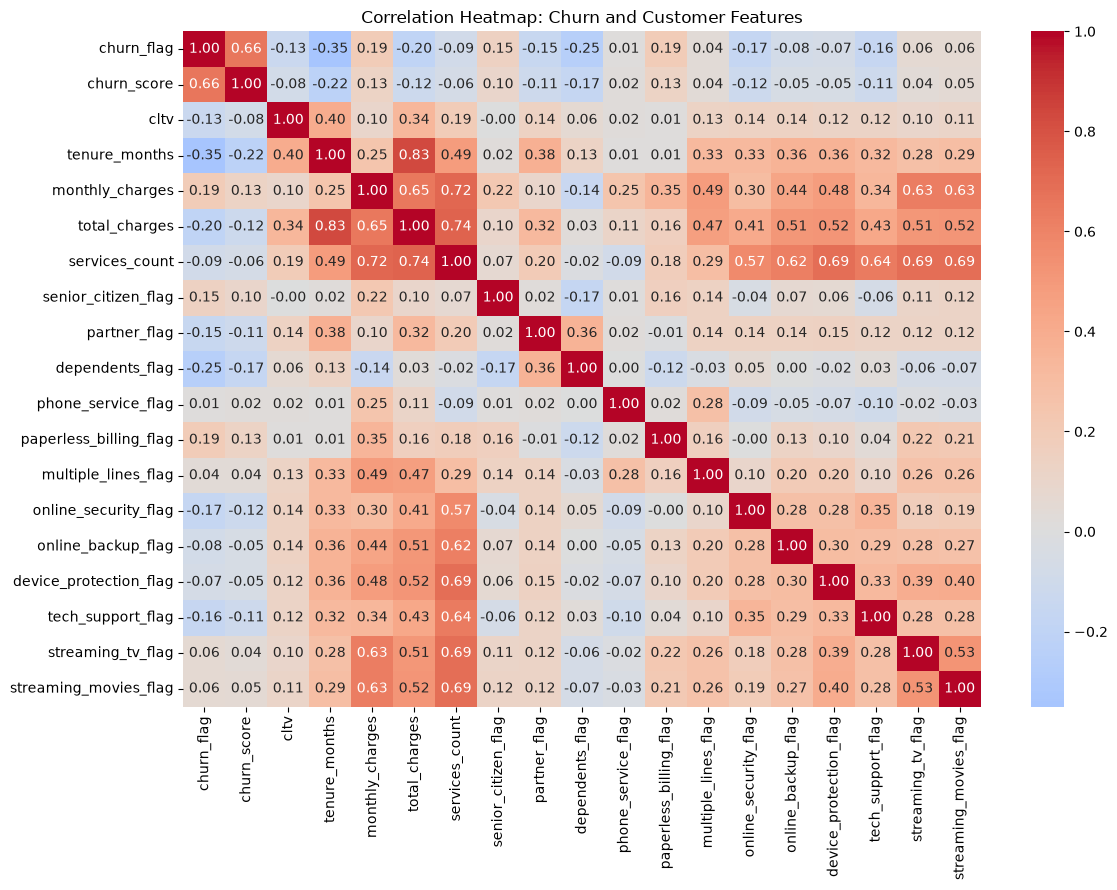

In [52]:
plt.figure(figsize=(12, 9))

# seaborn's heatmap turns the correlation grid into colors instead of raw numbers
# annot=True prints the actual number inside each cell too, not just color
# cmap='coolwarm' makes negative correlations blue, positive ones red - easy to scan visually
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, fmt='.2f')

plt.title('Correlation Heatmap: Churn and Customer Features')
plt.tight_layout()

In [53]:
import os
os.makedirs('../images', exist_ok=True)
plt.savefig('../images/correlation_heatmap.png', dpi=150)
plt.show()

<Figure size 640x480 with 0 Axes>

## Correlation Heatmap: Churn and Customer Features
wanted to see how all the numeric/flag columns relate to each other and specifically to churn_flag, instead of just checking one feature at a time like ive been doing so far.

biggest correlation by far is churn_score at 0.66 - but this one doesnt really count as a "finding". churn_score wasnt something i calculated, it came pre-built into the dataset (probably from IBMs own internal model), so this is basically just confirming that score does its job, not telling us anything new about why people actually leave. important to remember this for later - if i build my own prediction model in phase 4, churn_score needs to be left out of the features, otherwise im basically feeding the model the answer key. thats called data leakage.

the real useful ones:
- tenure_months at -0.35 - strongest genuine negative relationship, matches the tenure cohort finding from earlier (longer tenure = less churn)
- monthly_charges at +0.19 vs total_charges at -0.20 - interesting these go opposite directions. higher monthly price = slightly more churn risk (fits with the fiber optic finding), but total_charges is mostly just a mix of tenure and price, so it ends up negative since it reflects long-term customers
- dependents_flag at -0.25 and partner_flag at -0.15 - customers with family ties around (partner, dependents) churn less. hadnt looked at this one specifically before
- online_security_flag (-0.17) and tech_support_flag (-0.16) - these two specific services have a stronger individual stickiness effect than services_count as a whole average suggested

overall this backs up a lot of what ive already found (tenure, contract type, services) but from a different angle, and the churn_score/data leakage point is something i need to actually remember for phase 4, not just note here.

In [54]:
print(churn_by_contract)
print(churn_by_internet)
print(churn_by_payment)
print(churn_by_services_internet_only)
print(churn_by_tenure_cohort)
print(category_counts)

contract_type
Month-to-month    42.71
One year          11.27
Two year           2.83
Name: churn_flag, dtype: float64
internet_service
DSL            18.96
Fiber optic    41.89
No              7.40
Name: churn_flag, dtype: float64
payment_method
Bank transfer (automatic)    16.71
Credit card (automatic)      15.24
Electronic check             45.29
Mailed check                 19.11
Name: churn_flag, dtype: float64
services_count
0    52.24
1    45.76
2    35.82
3    27.37
4    22.30
5    12.43
6     5.28
Name: churn_flag, dtype: float64
tenure_cohort
New (0-12mo)             47.44
Growing (13-24mo)        28.71
Established (25-48mo)    20.39
Loyal (49-72mo)           9.51
Name: churn_flag, dtype: float64
cancellation_category
Competitor              621
Service/Support         454
Product/Network         382
Other/Non-actionable    213
Price                   199
Name: count, dtype: int64


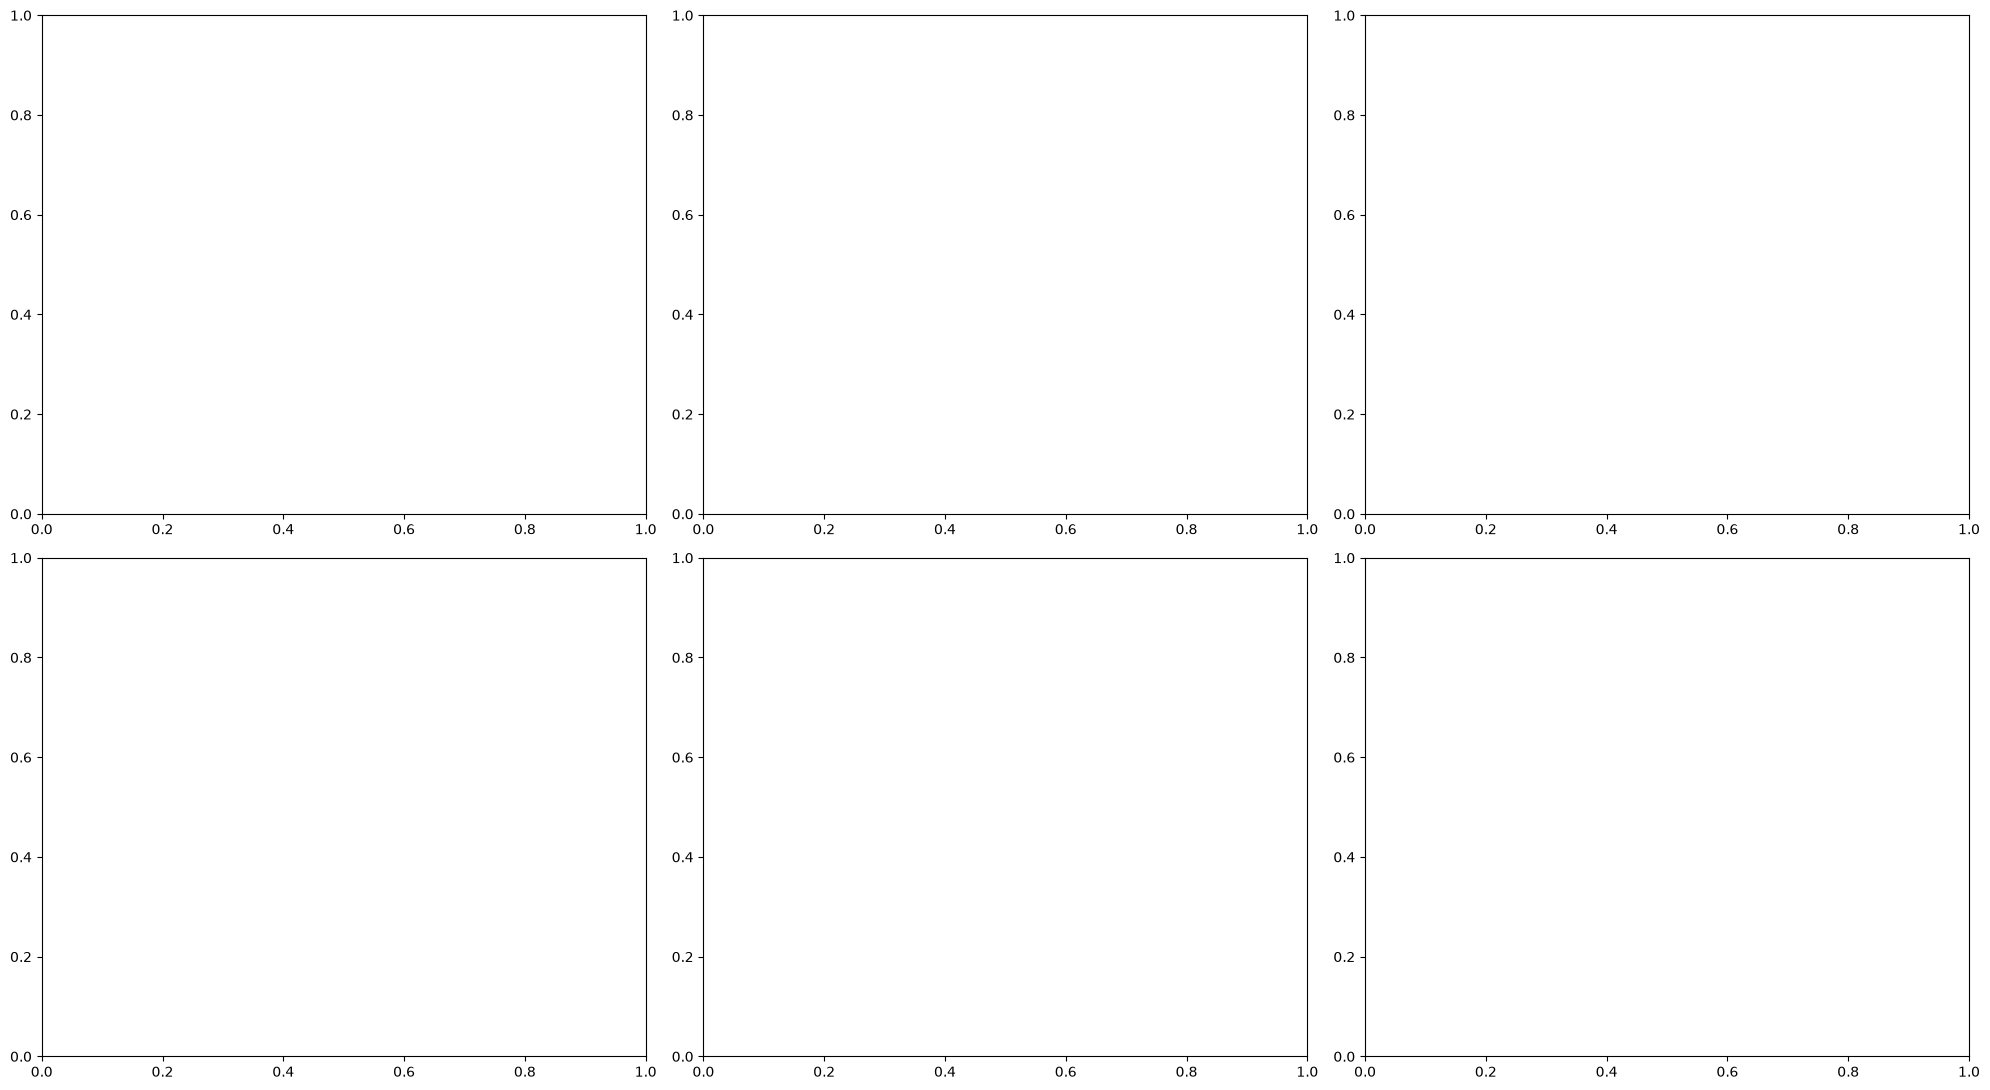

In [55]:
fig, axes = plt.subplots(2, 3, figsize=(20, 11))
# axes is a 2x3 grid of subplot objects - axes[0,0] is top-left, axes[1,2] is bottom-right, etc.
plt.tight_layout()
plt.show()

## 6. Diagnostic Dashboard

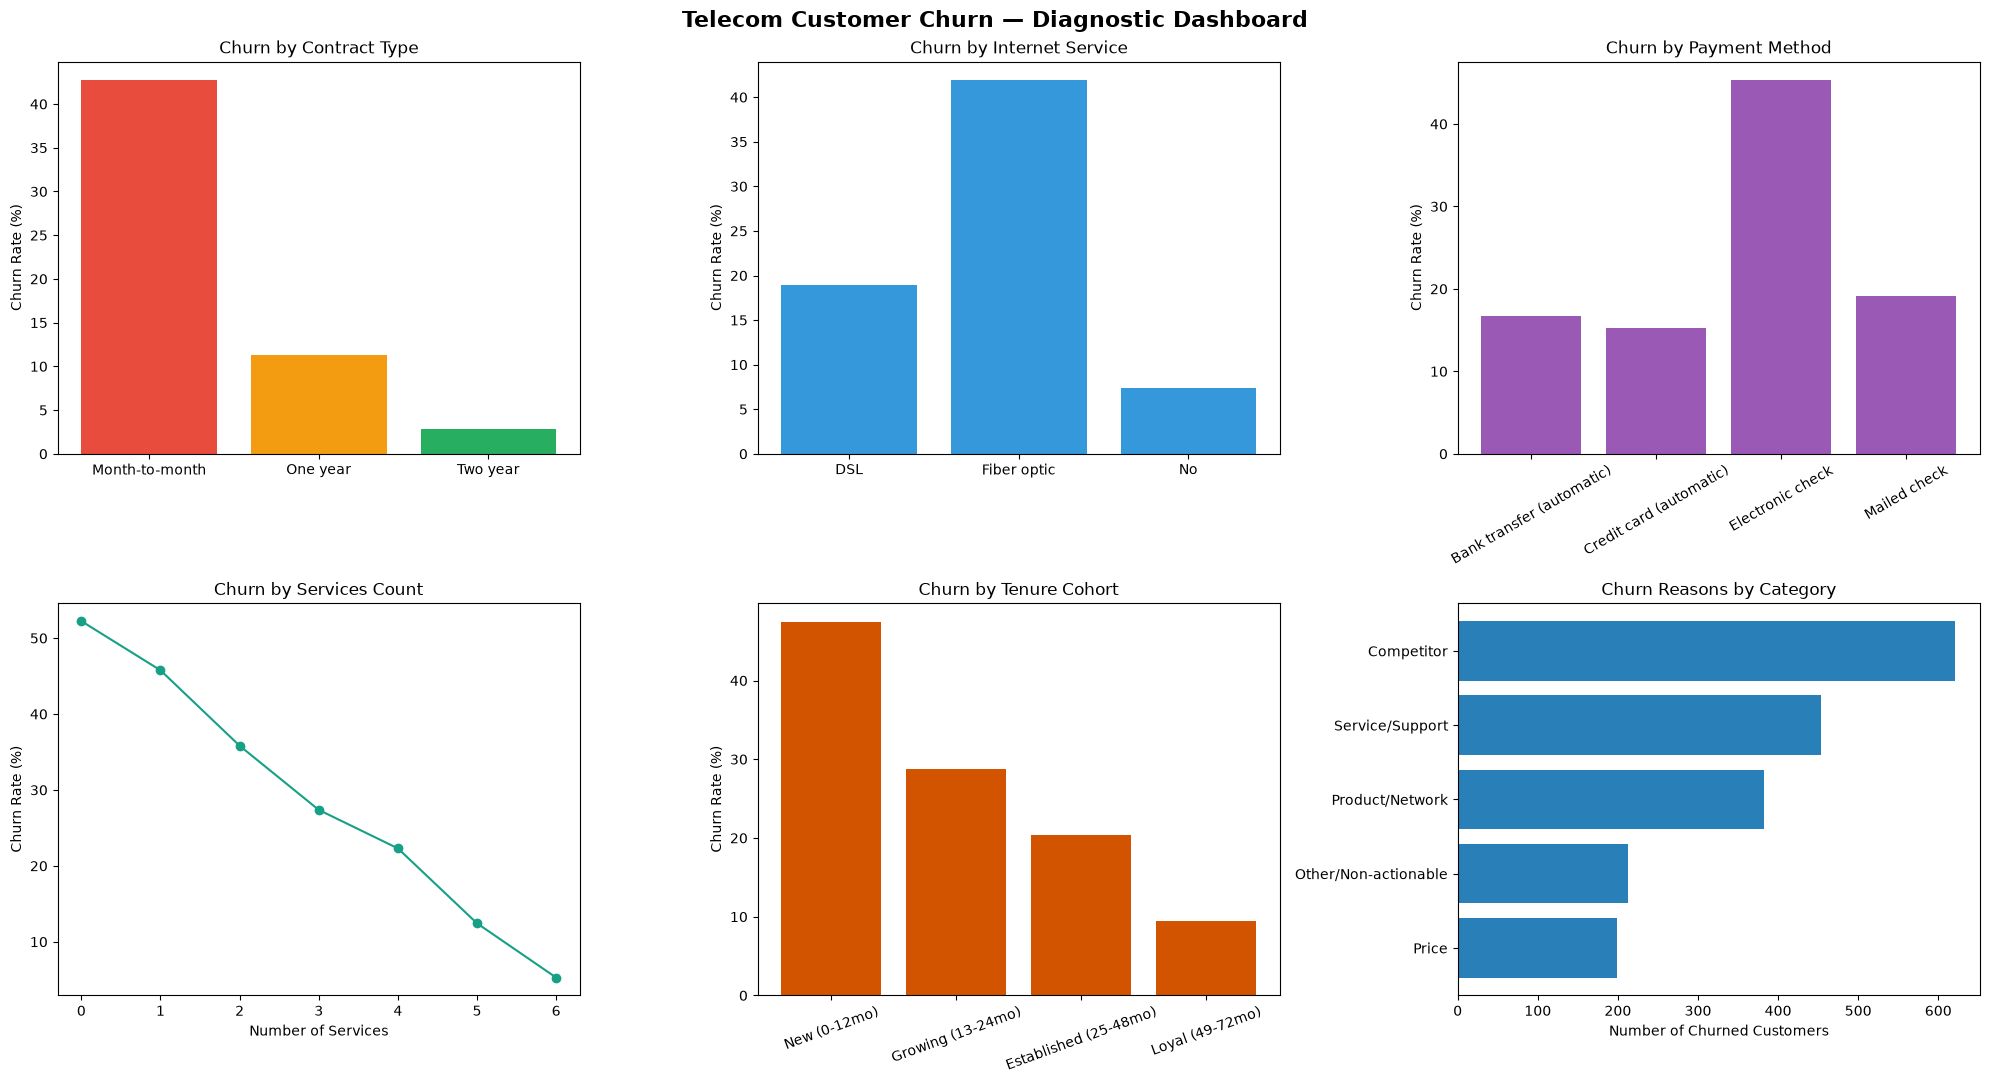

In [56]:
fig, axes = plt.subplots(2, 3, figsize=(20, 11))

# Panel 1: Contract Type
order_contract = ['Month-to-month', 'One year', 'Two year']
data1 = churn_by_contract.reindex(order_contract)
axes[0,0].bar(data1.index, data1.values, color=['#e74c3c', '#f39c12', '#27ae60'])
axes[0,0].set_title('Churn by Contract Type')
axes[0,0].set_ylabel('Churn Rate (%)')
axes[0,0].tick_params(axis='x', rotation=0)

# Panel 2: Internet Service
axes[0,1].bar(churn_by_internet.index, churn_by_internet.values, color='#3498db')
axes[0,1].set_title('Churn by Internet Service')
axes[0,1].set_ylabel('Churn Rate (%)')

# Panel 3: Payment Method
axes[0,2].bar(churn_by_payment.index, churn_by_payment.values, color='#9b59b6')
axes[0,2].set_title('Churn by Payment Method')
axes[0,2].set_ylabel('Churn Rate (%)')
axes[0,2].tick_params(axis='x', rotation=30)

# Panel 4: Services Count (internet-only)
axes[1,0].plot(churn_by_services_internet_only.index, churn_by_services_internet_only.values,
                marker='o', color='#16a085')
axes[1,0].set_title('Churn by Services Count')
axes[1,0].set_xlabel('Number of Services')
axes[1,0].set_ylabel('Churn Rate (%)')

# Panel 5: Tenure Cohort
axes[1,1].bar(churn_by_tenure_cohort.index, churn_by_tenure_cohort.values, color='#d35400')
axes[1,1].set_title('Churn by Tenure Cohort')
axes[1,1].set_ylabel('Churn Rate (%)')
axes[1,1].tick_params(axis='x', rotation=20)

# Panel 6: Cancellation Categories
axes[1,2].barh(category_counts.sort_values().index, category_counts.sort_values().values, color='#2980b9')
axes[1,2].set_title('Churn Reasons by Category')
axes[1,2].set_xlabel('Number of Churned Customers')

# Title, spacing, save
fig.suptitle('Telecom Customer Churn — Diagnostic Dashboard', fontsize=16, fontweight='bold')
plt.tight_layout()

import os
os.makedirs('../images', exist_ok=True)
plt.savefig('../images/churn_dashboard.png', dpi=150)
plt.show()

## 7. Key Findings & Recommendations

### Overview
This analysis examined 7,043 telecom customers to understand who is churning, why, and how much revenue is at stake. The overall churn rate is **26.54%** (73.46% retention), representing **$139,130.85 in monthly recurring revenue at risk** (~$1.67M annualized) and **$7.75M in total customer lifetime value** already lost to churned accounts.

### What Drives Churn Here

**1. Contract length is the single strongest lever.** Month-to-month customers churn at **42.71%**, roughly 15x higher than two-year contract customers (**2.83%**). This is also the largest customer segment (3,875 of 7,043), making it the highest-priority group for retention effort.

**2. Fiber optic customers churn more than any other service tier — driven largely by price.** Despite being the premium offering, Fiber Optic churns at **41.89%** vs. 18.96% for DSL. Fiber customers pay roughly 58% more per month on average ($91.50 vs. $58.10), suggesting price sensitivity is a major factor rather than service dissatisfaction alone.

**3. Payment friction correlates strongly with churn.** Electronic check users churn at **45.29%** — nearly 3x higher than automatic payment methods (15–17%) — and it's also the single largest payment segment (2,365 customers), making it a major overall contributor to churn volume.

**4. Add-on services build stickiness.** Among customers with internet service, churn drops steadily from **52.24%** with zero add-on services to just **5.28%** with all six — customers with no internet at all were excluded from this comparison after an initial confound was identified (see Section on Services Count analysis).

**5. Risk is concentrated in the first year.** New customers (0–12 months) churn at **47.44%**, compared to just **9.51%** for customers with 49+ months of tenure — retention risk is heavily front-loaded early in the customer lifecycle.

**6. Competitive pressure, not price, is the leading stated reason for leaving.** Among churned customers who gave a reason, **33.23%** cited a competitor (better offer, speed, data, or devices) — more than Price (10.65%) and Product/Network issues (20.44%) combined. Service/Support issues (24.29%) were the second-largest category.

### Business Recommendations
1. **Incentivize contract upgrades** — targeted offers (discounts, loyalty perks) to move month-to-month customers toward one-year contracts, which alone would cut their churn risk by nearly 4x.
2. **Investigate Fiber Optic pricing and service quality** specifically — this segment combines the highest churn rate with the highest average revenue per customer, making it the highest-value retention target.
3. **Drive AutoPay adoption** among Electronic Check users through small incentives — removing payment friction is a low-cost, high-leverage retention lever.
4. **Build a first-90-day onboarding and engagement program** — given how heavily churn risk is concentrated in year one, early intervention has outsized impact.
5. **Strengthen competitive positioning and proactive retention offers**, since competitor pressure — not price or product failure — is the leading driver of stated churn.

### Limitations
- This dataset covers a single U.S. state (California) and one point in time; findings are descriptive/diagnostic and correlational, not causal.
- `churn_score` (a field pre-built into the source dataset) correlates strongly with churn (r = 0.66) but was deliberately excluded from feature analysis where relevant, since it likely reflects an existing internal model rather than an independent signal — using it directly would risk data leakage in any predictive modeling built on this data.

### Next Steps
The natural extension of this analysis is a predictive model — using the engineered features here (tenure, contract type, services, payment method) to predict churn independently, rather than relying on the pre-existing `churn_score`. *(See Phase 4 / next notebook section.)*